# Data retrieval

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Obtaining a test dataset from scikit-learn for the model
# It's already clean and there are others as well on scikit-learn
from sklearn.datasets import load_breast_cancer

In [12]:
# An unorganized form of the dataset
data = load_breast_cancer()

# How are these datasets structured
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target 

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Data cleaning

In [11]:
# Classes: 0 - Benigne and 1 -
# Dataset is already clean 

In [14]:
# Storing your features asides the target
X = df.iloc[:,:-1]
# Storing your target
y = df['target']

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

# Data splitting

In [15]:
from sklearn.model_selection import train_test_split

In [17]:
# We use stratify here coz we have a fixed amount of outputs and want to specify the ratio for each of the two
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
# Standard scaler is applied coz each numerical feature has unique wide range of values
# that we'd want to normalize in a sense
ss = StandardScaler()

In [20]:
# fit_transform and transform are same just different names and you cna't use the former
# more than once
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# Model building

In [28]:
# Building the model

from sklearn.linear_model import LogisticRegression

# Linear regression doesn't have an amount of iteration to learn from data
# Logistic has a number of times it learns from data. We tweak this using 
# max_iter=. Some pcs req. higher values while others req lower
model = LogisticRegression()
# Give it our data to learn from
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Evaluate

## Prediction 

In [23]:
y_pred = model.predict(X_test)

## Metrics

In [38]:
# ConfusionMatrixDisplay is a module for displaying it ig
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [31]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.986013986013986

In [32]:
precision = precision_score(y_test, y_pred)
precision

0.9888888888888889

In [33]:
f1 = f1_score(y_test, y_pred)
f1

0.9888888888888889

In [34]:
recall = recall_score(y_test, y_pred)
recall

0.9888888888888889

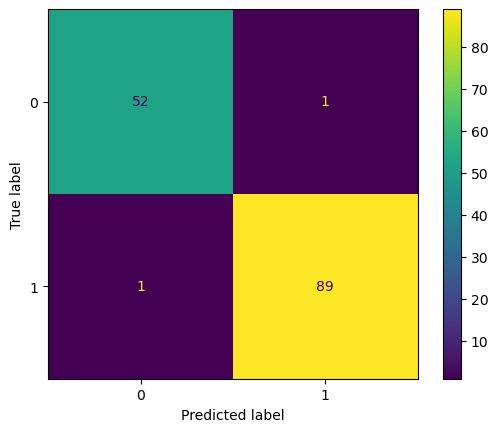

In [39]:
confusion_mx = confusion_matrix(y_test, y_pred)
matrix = ConfusionMatrixDisplay(confusion_mx, display_labels=model.classes_)
matrix.plot()

In [37]:
roc_auc_score = roc_auc_score(y_test, y_pred)
roc_auc_score

0.9850104821802935

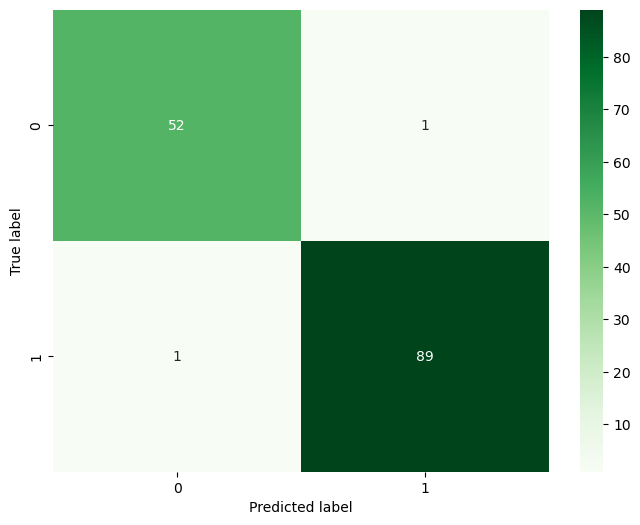

In [44]:
# What's a heatmap??)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_mx, annot=True, cmap='Greens')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [ ]:
# Which metric would you prioritize in this field of medicine
# Precision and Recall